# 19_参数估计方法-最小化均方误差

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这个小节，咱们来详细介绍一下参数估计方法之最小化均方误差\~

### 什么是参数估计？

参数估计就是我们在做机器学习或统计建模时，模型里有一些“未知”的数字，比如线性回归里的斜率、截距，我们要想办法通过已有数据把这些数值“估计”出来。

> 比如：你想知道一个人走路的速度（速度是参数），你观察他走了10米用了2秒，估计他的速度是 10 ÷ 2 = 5 米/秒。

### 什么是均方误差（MSE）？

均方误差，全称 Mean Squared Error，是衡量“预测值”与“真实值”之间差距的一个指标。

公式：


$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
$$


其中：

- $y_i$：真实值
- $\hat{y}_i$：预测值（模型输出）
- $n$：样本数量

也就是“每个点的预测误差平方，全部加起来，再求平均”。

### 什么是“最小化均方误差”？

这是一种**估计参数**的方法。我们在设计模型（比如线性回归）时，模型会输出预测值 $\hat{y}$，但一开始我们并不知道哪个参数最合适，于是我们想办法调整参数，让 **MSE 最小**。

> 就像你在做投篮训练，第一次扔得太左，第二次太右，你会不断调整角度，直到投得最准，也就是误差最小。

## 核心原理

以线性回归为例进行推导：

**模型假设**：

我们假设一个简单的一元线性模型：


$$
\hat{y}_i = \theta_0 + \theta_1 x_i
$$


其中：

- $\theta_0$：截距
- $\theta_1$：斜率
- $x_i$：输入变量
- $\hat{y}_i$：预测值

目标是找出最好的 $\theta_0$、$\theta_1$，使得预测值 $\hat{y}_i$ 尽可能接近真实值 $y_i$。

### 定义损失函数（目标函数）：


$$
J(\theta_0, \theta_1) = \frac{1}{n} \sum_{i=1}^n (y_i - (\theta_0 + \theta_1 x_i))^2
$$


我们的目标就是**最小化这个函数**。

### 求解步骤（以最小二乘法为例）：

我们可以用 **偏导数** 来求最小值。对 $\theta_0$、$\theta_1$ 分别求偏导：

#### 对 $\theta_0$ 求偏导：


$$
\frac{\partial J}{\partial \theta_0} = -\frac{2}{n} \sum_{i=1}^n (y_i - \theta_0 - \theta_1 x_i)
$$


#### 对 $\theta_1$ 求偏导：


$$
\frac{\partial J}{\partial \theta_1} = -\frac{2}{n} \sum_{i=1}^n x_i (y_i - \theta_0 - \theta_1 x_i)
$$


令导数为 0，解这两个方程，可以得到解析解：

### 一元线性回归的闭式解（最小化 MSE 的最优参数）：


$$
\theta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
$$


$$
\theta_0 = \bar{y} - \theta_1 \bar{x}
$$


这个解法就是通过“最小化均方误差”来估计最优参数。

## 算法流程

1. **定义模型**：确定模型形式，例如线性模型、非线性模型等。
2. **构造损失函数**：用均方误差定义损失函数 $J(\theta) = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$
3. **初始化参数**：随机选取参数初值或设为0。
4. **优化算法**：选择优化方法：

   - 如果有解析解（如线性回归），直接解方程。
   - 若无解析解，用数值方法（如梯度下降）最小化损失函数。
5. **迭代优化**（若用梯度下降）：

   - 计算梯度
   - 更新参数
   - 判断是否收敛（或达到最大迭代次数）
6. **输出最优参数**，用于预测或模型解释。

## 完整案例

假设一家房地产数据公司，现在有一批房屋的历史交易数据，希望预测一套房子的价格，**仅基于其面积（平方米）**。这是一种典型的**一元线性回归问题**。

我们将使用「最小化均方误差」的方法，估计线性模型的参数（斜率与截距），让预测值尽可能接近真实值。

我们假设数据关系为：


$$
\hat{y} = \theta_0 + \theta_1 x
$$


其中：

- $x$：房屋面积
- $y$：真实价格
- $\hat{y}$：预测价格
- $\theta_0$、$\theta_1$：待估参数

我们的目标是最小化均方误差：


$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$


### 代码实现

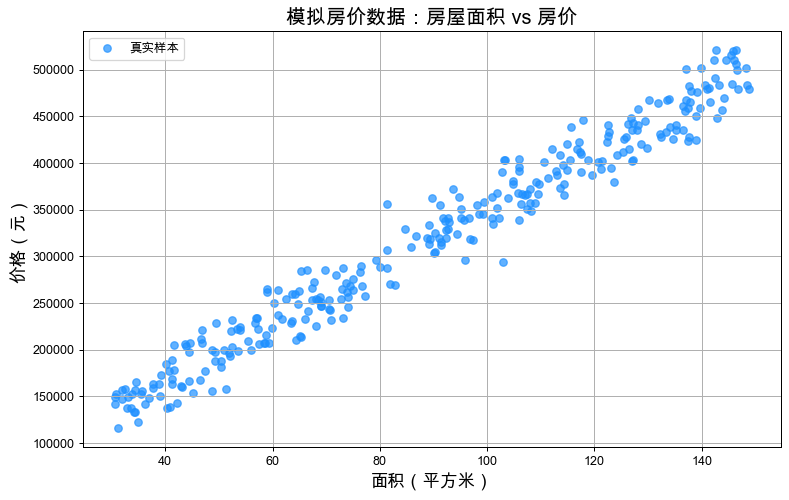

估计的参数：theta_0 = 45807.18, theta_1 = 3043.71


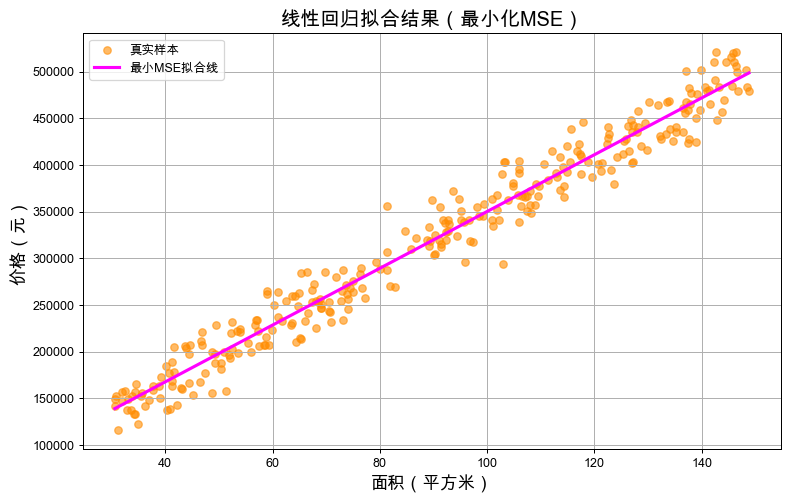

最终均方误差 MSE = 388508652.45


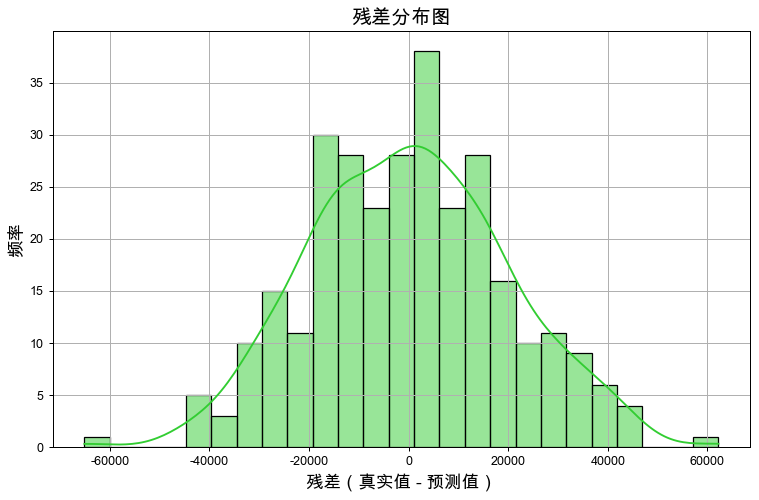

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# 1. 模拟数据
n_samples = 300
X = np.random.uniform(30, 150, n_samples)  # 房屋面积：30~150平米
true_theta_0 = 50000  # 截距：最基本价格
true_theta_1 = 3000   # 每平米价格
noise = np.random.normal(0, 20000, n_samples)  # 噪声项
y = true_theta_0 + true_theta_1 * X + noise  # 实际房价（带噪声）

# 2. 可视化原始数据
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='dodgerblue', alpha=0.7, label='真实样本')
plt.title('模拟房价数据：房屋面积 vs 房价', fontsize=16)
plt.xlabel('面积（平方米）', fontsize=14)
plt.ylabel('价格（元）', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# 3. 手动实现线性回归参数估计（最小化MSE）
X_mean = np.mean(X)
y_mean = np.mean(y)

# 计算斜率 theta_1
numerator = np.sum((X - X_mean) * (y - y_mean))
denominator = np.sum((X - X_mean)**2)
theta_1_hat = numerator / denominator

# 计算截距 theta_0
theta_0_hat = y_mean - theta_1_hat * X_mean

print(f"估计的参数：theta_0 = {theta_0_hat:.2f}, theta_1 = {theta_1_hat:.2f}")

# 4. 可视化拟合直线
y_pred = theta_0_hat + theta_1_hat * X

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='darkorange', alpha=0.6, label='真实样本')
plt.plot(np.sort(X), y_pred[np.argsort(X)], color='magenta', linewidth=2.5, label='最小MSE拟合线')
plt.title('线性回归拟合结果（最小化MSE）', fontsize=16)
plt.xlabel('面积（平方米）', fontsize=14)
plt.ylabel('价格（元）', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# 5. 计算均方误差
mse = mean_squared_error(y, y_pred)
print(f"最终均方误差 MSE = {mse:.2f}")

# 6. 可视化残差分布
residuals = y - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=25, color='limegreen', kde=True)
plt.title("残差分布图", fontsize=16)
plt.xlabel("残差（真实值 - 预测值）", fontsize=14)
plt.ylabel("频率", fontsize=14)
plt.grid(True)
plt.show()

#### 第1步：模拟数据

我们使用了一个线性函数加上噪声来生成数据：


$$
y = 50000 + 3000 \cdot x + \varepsilon,\quad \varepsilon \sim \mathcal{N}(0, 20000^2)
$$


这个模拟非常接近现实：房价与面积呈线性相关，但会有波动（噪声）来源于楼层、地段等不可控因素。

#### 第2步：数据可视化

用 `scatter` 可视化房价 vs 面积，可以清楚看到数据大致呈现线性上升趋势，但带有一定波动。

![原文参考图，当前结果见代码输出](attachments/img_006.png)

#### 第3步：最小化均方误差估计参数

我们使用的是**最小二乘法的闭式解**：

- 均值中心化之后，斜率计算为：


$$
\hat{\theta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
$$


- 截距则为：


$$
\hat{\theta}_0 = \bar{y} - \hat{\theta}_1 \cdot \bar{x}
$$


这是线性回归中最基础但最核心的 MSE 最小化方案。这里不使用 sklearn 的黑箱，手动实现，大家可以看清楚其中实现的步骤。

#### 第4步：拟合可视化

可以清晰看到，这条线大致“穿过”数据点群中心，是最优的估计线。

![原文参考图，当前结果见代码输出](attachments/img_007.png)

#### 第5步：计算最终误差

我们调用 `mean_squared_error`，评估模型好坏：


$$
\text{MSE} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$


MSE 数值越小，代表模型预测越接近真实数据。

#### 第6步：残差分析

残差 $e_i = y_i - \hat{y}_i$，衡量预测误差的分布。

我们绘制了残差直方图，绿色代表残差频率密度分布，并用 `kde=True` 绘出平滑曲线。图像大致呈对称分布，符合高斯假设，说明模型拟合良好。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

### 最小化均方误差优缺点分析

**优点**：

1. **直观易懂**：误差平方和最小，符合人们对“误差越小越好”的直觉。
2. **数学推导简洁**：在很多模型（如线性回归）中可直接得出解析解。
3. **具有良好的统计性质**：在噪声服从高斯分布的情况下，MSE 最小化对应于最大似然估计。
4. **容易求导优化**：平方函数连续可导，利于使用梯度下降法等数值算法。
5. **可扩展性强**：神经网络中的回归问题也常使用 MSE。

**缺点**：

1. **对异常值非常敏感**：因为误差被平方，离群点会严重拉高整体损失，影响参数估计。
2. **不是鲁棒方法**：一旦数据存在噪声污染，估计参数可能失真。
3. **不能直接用于分类问题**：分类场景（如判断是猫还是狗）使用 MSE 效果很差，梯度更新缓慢。
4. **假设偏强**：仅适用于误差服从正态分布的情况，一旦偏离就不再最优。

### 最小化均方误差最佳场景与局限性讨论

**适用的情况**：

- **回归任务**：输出是连续变量（如价格、温度、销量）
- **数据无明显离群点**：否则平方误差会导致过拟合
- **误差大致呈正态分布**：理论保证最优性
- **模型线性或近似线性**：可以快速收敛并解释

**不适用的情况**：

- 分类任务（如垃圾邮件判断、图片识别）
- 数据中含有大量异常点或强噪声
- 对解释性要求高但误差不能平方（如中位误差更合适）
- 输出是概率值（通常使用交叉熵更合适）

## 总结

最小化均方误差不仅是回归问题的核心工具，也是机器学习基本框架的理论基石，它的应用虽然广泛，但必须**在适当的场景**下使用才能真正有效。